In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
import scipy.stats as stats #forQ-Q plot

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [19]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [23]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [22]:
# df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [27]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state =  42)

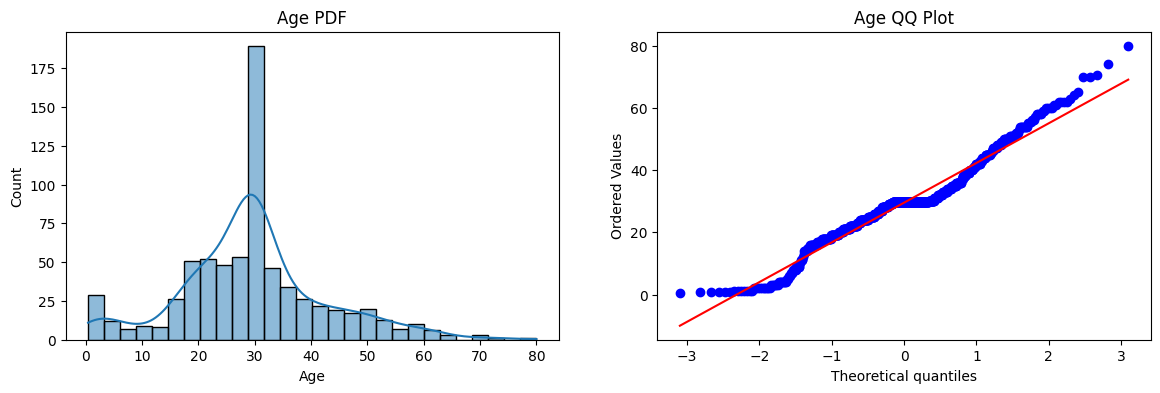

In [39]:
plt.figure(figsize=(14,4))
plt.subplot(121) # (mean 1 row 2 column and 1st graph)
sns.histplot(X_train['Age'],kde=True,)
plt.title('Age PDF')

plt.subplot(122) # (mean 1 row 2 column and 2st graph)
stats.probplot(X_train['Age'],  dist="norm", plot = plt) #Creates a QQ Plot: Quantile vs Quantile Plot => It compares: Actual data quantiles vs Normal distribution quantiles
plt.title('Age QQ Plot')
plt.show()

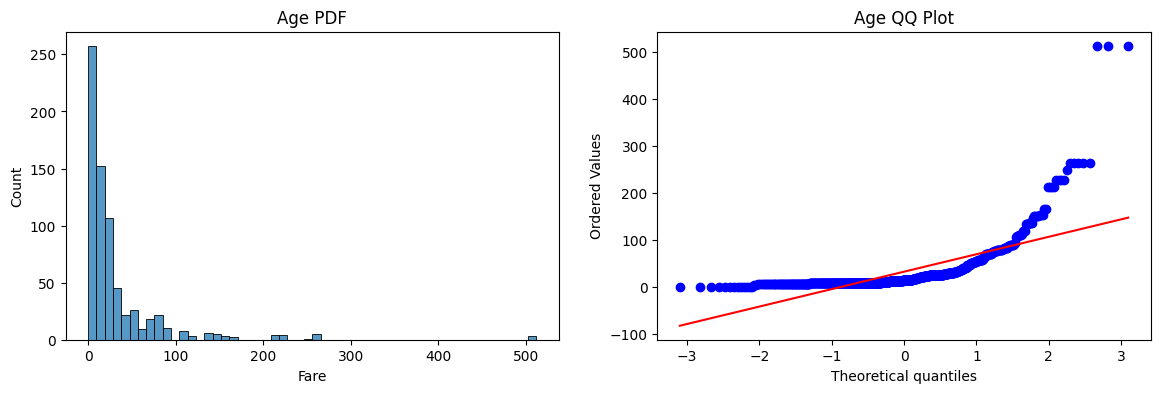

In [41]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist ="norm", plot = plt)
plt.title('Age QQ Plot')
plt.show()

In [42]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [43]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR" , accuracy_score(y_test,y_pred))
print("Accuract DT", accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuract DT 0.6480446927374302


In [47]:
# applying the transformation with log +1  
trf = FunctionTransformer(func=np.log1p)

In [48]:
# Fit and transform 
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [49]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268


In [50]:
X_transformed = trf.fit_transform(X)

In [51]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [52]:
print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DL",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DL 0.678027465667915


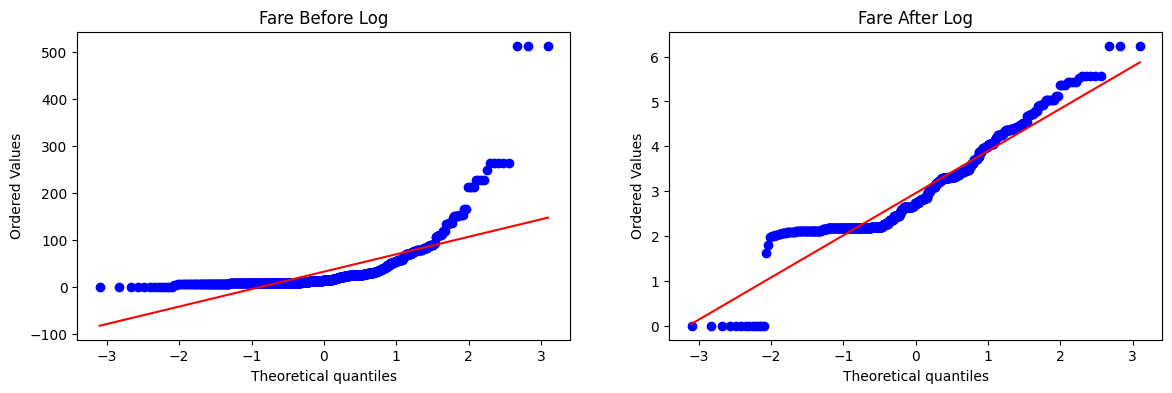

In [54]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm",plot = plt)
plt.title('Fare After Log')
plt.show()

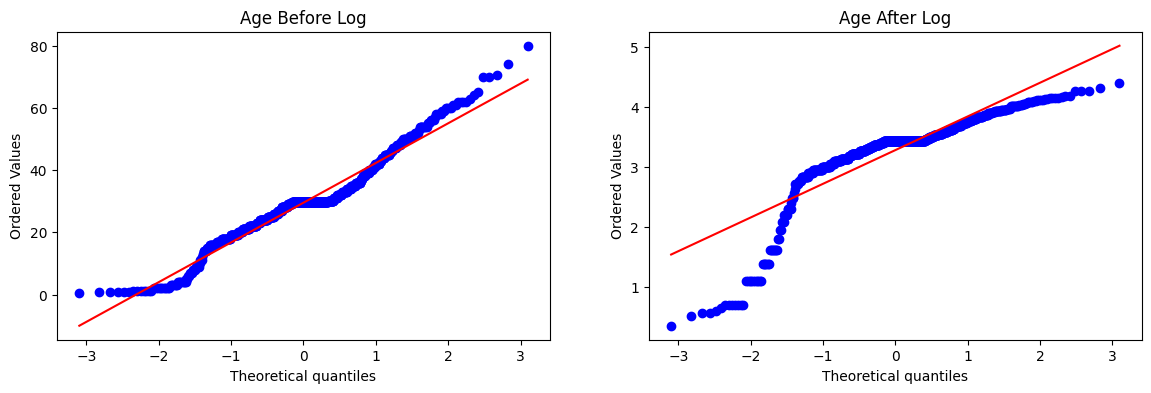

In [55]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'], dist = "norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot = plt)
plt.title('Age After Log')

plt.show()

In [64]:
trf2 = ColumnTransformer([
    ('log',FunctionTransformer(np.log1p),['Fare'])
],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test) 

In [67]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6815642458100558


In [70]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    trf = ColumnTransformer([
    ('log',FunctionTransformer(transform),['Fare'])
    ],remainder='passthrough')
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6431335830212235


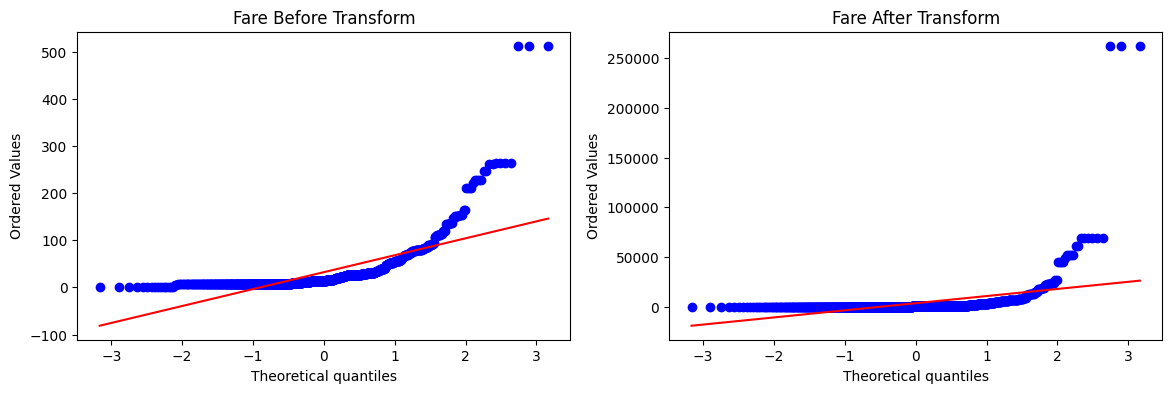

In [71]:
apply_transform(lambda x : x**2)

Accuracy 0.61729088639201


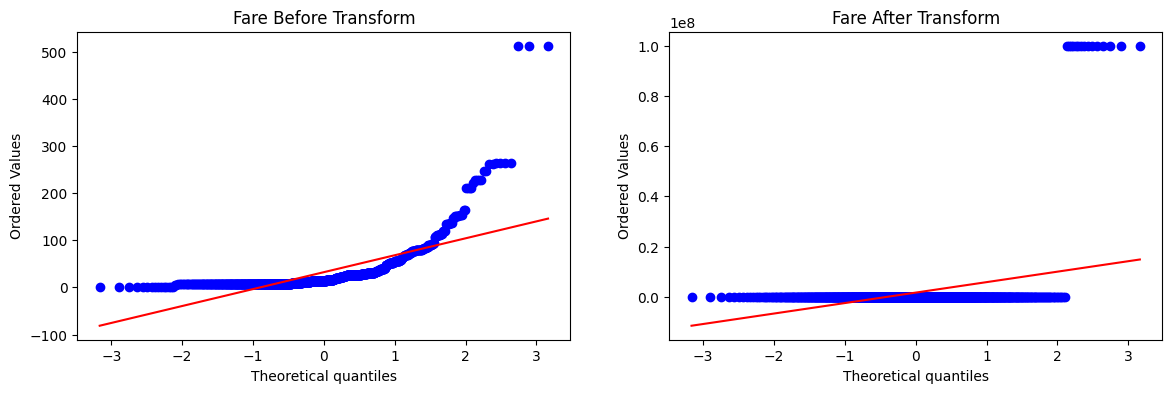

In [73]:
apply_transform(lambda x : 1/(x + 0.00000001))